# 5. Respiration & RSA (Principles: vagal brake, cardiorespiratory coupling)

In [ ]:
import os, pickle, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.signal import find_peaks, welch
from scipy.interpolate import interp1d

notebook_dir = os.getcwd()

In [6]:
respiration_frequency_sampling_rate = 25.0

In [3]:
data_path = os.path.join(notebook_dir, "../../../data/WESAD/all_subjects/chest.csv")
df = pd.read_csv(data_path)
df.drop(['Unnamed: 0'], axis=1, inplace=True)
df

,ACC_x,ACC_y,ACC_z,ECG,EMG,EDA,Temp,Resp,subject,label
0,0.9554,-0.2220,-0.5580,0.021423,-0.004440,5.250549,30.120758,-1.148987,S2,0
1,0.9258,-0.2216,-0.5538,0.020325,0.004349,5.267334,30.129517,-1.124573,S2,0
2,0.9082,-0.2196,-0.5392,0.016525,0.005173,5.243301,30.138214,-1.152039,S2,0
3,0.8974,-0.2102,-0.5122,0.016708,0.007187,5.249405,30.129517,-1.158142,S2,0
4,0.8882,-0.2036,-0.4824,0.011673,-0.015152,5.286407,30.130950,-1.161194,S2,0
...,...,...,...,...,...,...,...,...,...,...
60807595,0.9006,-0.0400,-0.1898,0.173676,-0.005539,7.265091,33.862762,0.318909,S17,0
60807596,0.9022,-0.0398,-0.1872,0.168777,-0.004944,7.266617,33.859740,0.233459,S17,0
60807597,0.9028,-0.0424,-0.1864,0.167130,-0.016068,7.262802,33.864290,0.318909,S17,0
60807598,0.9002,-0.0408,-0.1854,0.170334,0.005173,7.269669,33.862762,0.308228,S17,0


In [4]:
def get_per_subject(df):
    per_subject = {}
    entries = df['subject'].unique()
    for entry in entries:
        filt_subject = (df['subject'] == entry)
        subject_df = df[filt_subject]
        subject_df.reset_index(inplace=True)
        per_subject[entry] = subject_df
    return per_subject

per_subject_dfs = get_per_subject(df)
per_subject_dfs

{'S2':            index   ACC_x   ACC_y   ACC_z       ECG       EMG       EDA  \
 0              0  0.9554 -0.2220 -0.5580  0.021423 -0.004440  5.250549   
 1              1  0.9258 -0.2216 -0.5538  0.020325  0.004349  5.267334   
 2              2  0.9082 -0.2196 -0.5392  0.016525  0.005173  5.243301   
 3              3  0.8974 -0.2102 -0.5122  0.016708  0.007187  5.249405   
 4              4  0.8882 -0.2036 -0.4824  0.011673 -0.015152  5.286407   
 ...          ...     ...     ...     ...       ...       ...       ...   
 4255295  4255295  0.8750 -0.1234 -0.2974 -0.013138  0.020370  0.400162   
 4255296  4255296  0.8750 -0.1262 -0.2988 -0.010345  0.019592  0.355911   
 4255297  4255297  0.8718 -0.1238 -0.3042 -0.005447 -0.017166  0.360489   
 4255298  4255298  0.8730 -0.1234 -0.3026  0.000137 -0.028976  0.365829   
 4255299  4255299  0.8702 -0.1220 -0.3022  0.004074 -0.023575  0.365448   
 
               Temp      Resp subject  label  
 0        30.120758 -1.148987      S2      0 

In [5]:
s_df = per_subject_dfs['S7']
resp_df = s_df.loc[:, ['Resp']]
resp_df

,Resp
0,1.832581
1,1.835632
2,1.856995
3,1.829529
4,1.817322
...,...
3666595,0.813293
3666596,0.816345
3666597,0.804138
3666598,0.834656


<Axes: >

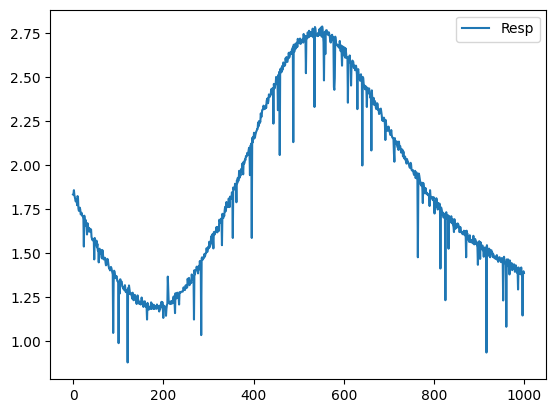

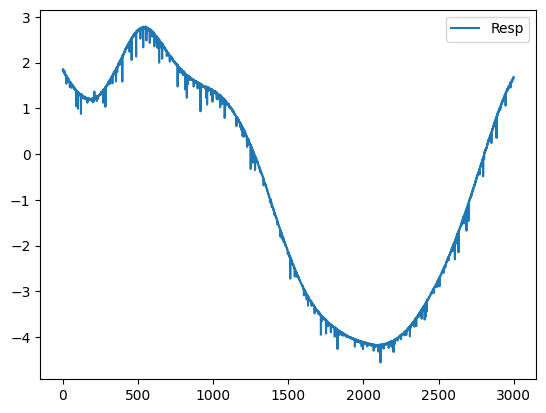

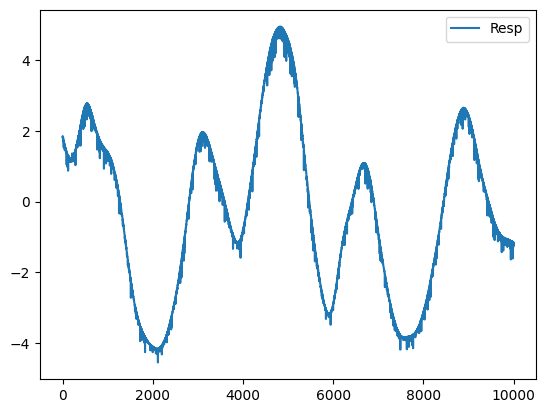

In [11]:
# resp_df.plot.line()
resp_df[:1000].plot.line()
resp_df[:3000].plot.line()
resp_df[:10000].plot.line()